In [2]:
import numpy as np

import sys
import os
import warnings

warnings.simplefilter("ignore", FutureWarning)

In [3]:
from attack_training import optimize, compute_loss

# Add the ability to import modules from the ocr/utils directory
sys.path.append(os.path.abspath("../utils"))

from google_vision import query_google_vision, predict_and_annotate
from image_tools import show_image, render_text, render_subtitles, get_frame_at_time


In [5]:
frame = get_frame_at_time("../../demo_data/obama_test_video_short.mp4", t=2)

def render_function(text, params):
    FONT_PATH = '../resources/fonts/zxx-noise.ttf'

    p = {
        "text_color": (255, 255, 255),
        "background_color": (0, 0, 0)
    }

    p.update(params)
    return render_subtitles(subtitles=[{'text': text}], frame=frame, params=p, font_path=FONT_PATH, font_size=40, max_chars=30)

def loss_function(pred_text, truth_text, symbol_confs, word_count):
    ALPHA = 0.0 # strength of confidence term
    BETA = 1.5  # strenght of edit distance term
    GAMMA = 0.75 # strength of detection term

    return compute_loss(pred_text, truth_text, symbol_confs, word_count, alpha=ALPHA, beta=BETA, gamma=GAMMA)

def theta_to_params(theta):
    return {
        "per_char_rot_std": np.clip(abs(theta[0])*10, 0, 20),
        "kerning_std": np.clip(theta[1]*6, -12, 12),
        "baseline_amp": np.clip(theta[2]*10, 0, 10),
        "baseline_freq": np.clip(theta[3]*5, 1, 10),
        "y_jitter_std": np.clip(theta[4]*5, 0, 10)
    }

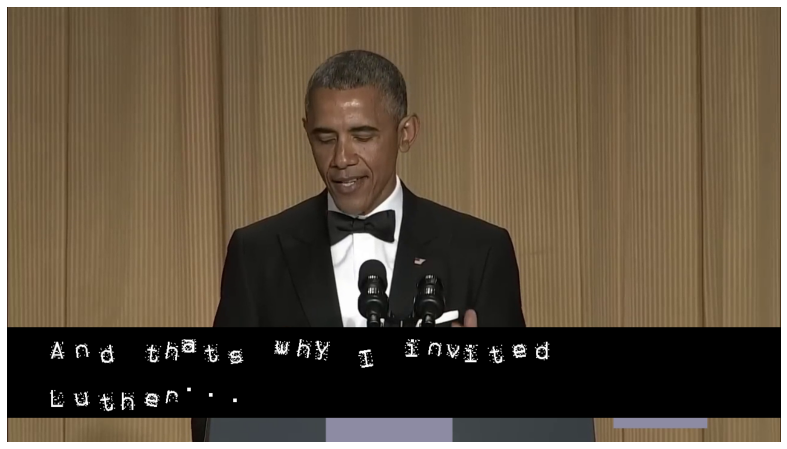

{'text': 'And\nthat s\nwhy I\nInvited',
 'symbol_confs': [0.9855692386627197,
  0.9804525971412659,
  0.9826050400733948,
  0.28467103838920593,
  0.44410181045532227,
  0.3534541726112366,
  0.5437371730804443,
  0.4255240559577942,
  0.8970914483070374,
  0.9176618456840515,
  0.6341298818588257,
  0.5950224995613098,
  0.398184210062027,
  0.593887448310852,
  0.8324564695358276,
  0.9061973690986633,
  0.9493200778961182,
  0.9055877923965454,
  0.9363429546356201],
 'word_count': 6}

In [6]:
p = {
    "per_char_rot_std": 10.0,
    "kerning_std": 5,
    "baseline_amp": 5.0,
    "baseline_freq": 5.0,
    "y_jitter_std": 5.0,
}

show_image(render_function("And thats why I invited Luther...", params=p))

query_google_vision(render_function("And thats why I invited Luther...", params=p))

In [7]:
theta = np.array([
    0.0,  # per_char_rot_std
    0.0,  # kerning_std
    0.0,  # baseline_amp
    0.0,  # baseline_freq
    0.0,  # y_jitter_std
])

In [55]:
#test_labels = ['the quick brown', 'fox jumped over', 'the lazy dog',
#               'hello world', 'computer and data', 'privacy']

# test_labels = ['Honestly, what they say doesnt bother me.', 'I understand weve got an adversarial system.',
#               'Im a mellow sort of guy.', 'And thats why I invited Luther...']

test_labels = 'Honestly, what they say doesnt bother me.'

theta = optimize(theta,
                 test_labels,
                 
                 query_function=query_google_vision,
                 loss_function=loss_function,
                 rendering_function=render_function,
                 param_mapping_function=theta_to_params,

                 steps=30,
                 sigma=1,
                 lr=0.7,
                 n_samples=40
                )

Step 000 | Loss: 0.6701 | Theta: [ 0.04718635 -0.00412406 -0.05804517 -0.03516668  0.0466621 ]
Step 001 | Loss: 0.6464 | Theta: [ 0.03671951 -0.02636128 -0.10951896 -0.08614005  0.02344617]
Step 002 | Loss: 0.5302 | Theta: [ 0.00416093 -0.05945264 -0.11732348 -0.11091105 -0.00296999]
Step 003 | Loss: 0.6406 | Theta: [ 0.04775458 -0.12938822 -0.1292719  -0.04738618 -0.10153114]
Step 004 | Loss: 0.6250 | Theta: [ 0.04359893 -0.16410892 -0.30319488  0.00735398 -0.18210827]
Step 005 | Loss: 0.6627 | Theta: [ 0.03247974 -0.23689074 -0.32811871  0.03729639 -0.18735934]
Step 006 | Loss: 0.6018 | Theta: [ 0.0310744  -0.24116945 -0.30104143  0.08742288 -0.2382721 ]
Step 007 | Loss: 0.5637 | Theta: [ 0.02386235 -0.25145015 -0.32607227  0.06464375 -0.27457831]
Step 008 | Loss: 0.5586 | Theta: [ 0.07753084 -0.25861559 -0.30426928  0.12423095 -0.27783104]
Step 009 | Loss: 0.6165 | Theta: [ 0.01709677 -0.32957557 -0.36136863  0.13216365 -0.30640431]
Step 010 | Loss: 0.7021 | Theta: [-0.06860457 -0.3

In [8]:
#theta = [-0.09023912,  2.14215873,  2.347406,    1.39300417,  2.58414025]
theta = [0.29505478, -1.36748775, 0.28154181, -0.17330353, 0.90088584]

In [9]:
theta_to_params(theta)

{'per_char_rot_std': 2.9505478000000003,
 'kerning_std': -8.2049265,
 'baseline_amp': 2.8154181,
 'baseline_freq': 1.0,
 'y_jitter_std': 4.504429200000001}

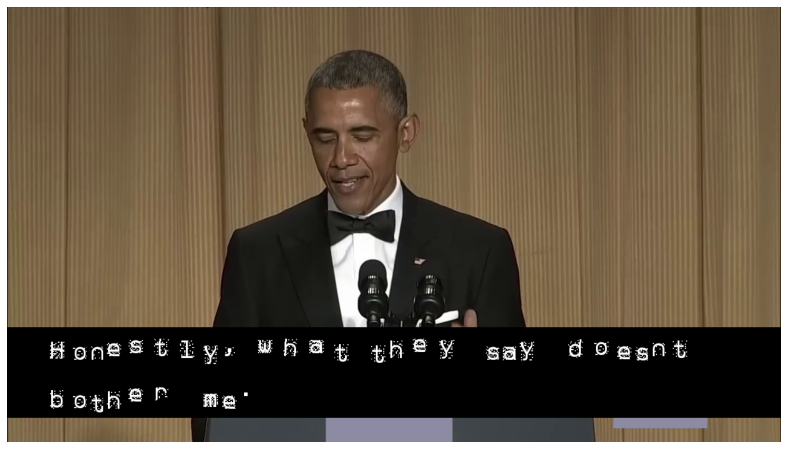

{'text': 'Honestly what they\nbothe\ndoesnt',
 'symbol_confs': [0.9342734217643738,
  0.9367770552635193,
  0.9628342390060425,
  0.9661778807640076,
  0.9450255036354065,
  0.9446276426315308,
  0.9653909206390381,
  0.9785671234130859,
  0.9373756051063538,
  0.9570632576942444,
  0.9384135007858276,
  0.9793912172317505,
  0.9777458906173706,
  0.9614805579185486,
  0.9525300860404968,
  0.8981682062149048,
  0.6896772384643555,
  0.4948253631591797,
  0.767725944519043,
  0.7197267413139343,
  0.8657320737838745,
  0.8361377120018005,
  0.668775200843811,
  0.7193868160247803,
  0.5972580313682556,
  0.8080697655677795,
  0.8923910856246948],
 'word_count': 5}

In [10]:
img = render_function('Honestly, what they say doesnt bother me.', params=theta_to_params(theta))
show_image(img)#predict_and_annotate(img))
query_google_vision(img)

In [ ]:
theta_to_params(theta)

In [11]:
validation_labels = [
    "quick brown fox",
    "lazy jumping dog",
    "quiet valley breeze",
    "bright silver moon",
    "jovial wizard",
    "crisp autumn wind",
    "heavy black quartz",
    "zesty lemon cake",
    "vivid jungle path",
    "broken clay pot",
    "gentle river bank",
    "frozen lake shore",
    "simple wooden box",
    "tiny blue cabin",
    "wild forest trail",
    "fresh baked bread",
    "calm ocean wave",
    "dusty gravel road",
    "sharp kitchen knife",
    "glowing amber light",
    "noisy market square",
    "proud royal knight",
    "rapid silver train",
    "golden wheat field",
    "ancient stone wall",
    "steady drum beat",
    "clear night sky",
    "quiet zebra grazing",
    "brisk mountain air",
    "young clever mind"
]

for label in validation_labels:
    img = render_function(label, params=theta_to_params(theta))
    out_text = query_google_vision(img)['text']

    status = '[ ]'
    if label == out_text:
        status = '[+]'

    print(f"{status} | {repr(label)} --> {repr(out_text)}")

[ ] | 'quick brown fox' --> 'Quick\nbrown fox'
[+] | 'lazy jumping dog' --> 'lazy jumping dog'
[ ] | 'quiet valley breeze' --> 'Valley'
[ ] | 'bright silver moon' --> 'bright\nU OOM'
[ ] | 'jovial wizard' --> 'j ovi a l\nwizard'
[ ] | 'crisp autumn wind' --> 'Crisp\nuuntne\nwind'
[ ] | 'heavy black quartz' --> 'heavo black'
[ ] | 'zesty lemon cake' --> 'Zesty Lemon'
[ ] | 'vivid jungle path' --> 'Vivid\njungle\npath'
[ ] | 'broken clay pot' --> 'clay\npot\nu e you q'
[ ] | 'gentle river bank' --> 'Yenti\nniven bank'
[ ] | 'frozen lake shore' --> ''
[ ] | 'simple wooden box' --> ''
[ ] | 'tiny blue cabin' --> '七'
[ ] | 'wild forest trail' --> 'pl I m\n饼\nforest'
[ ] | 'fresh baked bread' --> 'fresh\nbaked bread'
[ ] | 'calm ocean wave' --> ''
[ ] | 'dusty gravel road' --> 'dusty grave 1\nRoad'
[ ] | 'sharp kitchen knife' --> 'Kitchen knife'
[ ] | 'glowing amber light' --> 'uague BY TO'
[ ] | 'noisy market square' --> 'noisy market\nSquare'
[ ] | 'proud royal knight' --> 'Proud\nroyal\nK